# Unified Agent Comparison Notebook

This notebook provides a unified framework to compare different agents (PRF, Reranking) against BM25 baseline.
Configure parameters in Cell 1 to select which agent to run.

In [ ]:
# ============================================================================
# CELL 1: CONSTANTS AND PARAMETERS
# ============================================================================

# ===== FILE PATHS =====
DATA_FILE = "msmarco_queries_qrels.csv"

# ===== RETRIEVAL PARAMETERS =====
TOP_K = 30
TOP_K_PRF = 10  # Number of top documents to use for PRF expansion
TOP_K_REFORMULATE = 10  # Number of top documents to use for reformulation
NUM_QUERIES = 30

# ===== AGENT PARAMETERS =====
NUM_EXPANSION_TERMS = 2  # For PRF agent
VERBOSE = False  # Set to True to print detailed agent execution logs

# ===== AGENT SELECTION =====
# Multi-agent selection: [PRF, Reranking, Reformulate]
# You can select 0 to 3 agents
# Valid combinations:
#   [0,0,0] = Baseline only
#   [1,0,0] = PRF only
#   [0,1,0] = Reranking only
#   [0,0,1] = Reformulate only
#   [1,1,0] = PRF + Reranking (PRF applied first, then Reranking)
#   [1,0,1] = PRF + Reformulate (not recommended - use one or the other)
#   [0,1,1] = Reformulate + Reranking (Reformulate applied first, then Reranking)
#   [1,1,1] = PRF + Reformulate + Reranking (PRF applied first, then Reformulate expansion, then Reranking)
AGENT_SELECTION = [0, 0, 1]  # Change this to select agents

# Validate agent selection
num_selected = sum(AGENT_SELECTION)
if num_selected > 3:
    raise ValueError(f"Maximum 3 agents allowed, but {num_selected} were selected!")

AGENT_NAMES = ["PRF", "Reranking", "Reformulate"]
selected_agents = [AGENT_NAMES[i] for i, selected in enumerate(AGENT_SELECTION) if selected]
agent_combination_name = " + ".join(selected_agents) if selected_agents else "Baseline"

print(f"✓ Configuration loaded")
print(f"  Data file: {DATA_FILE}")
print(f"  Top-K: {TOP_K}")
print(f"  Selected Agent(s): {agent_combination_name}")
print(f"  Number of queries: {NUM_QUERIES}")

✓ Configuration loaded
  Data file: msmarco_queries_qrels.csv
  Top-K: 30
  Selected Agent(s): Reformulate
  Number of queries: 30


In [2]:
# ============================================================================
# CELL 2: SETUP - All imports, initialization, and utility functions
# ============================================================================

import sys
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple
import logging
import matplotlib.pyplot as plt
from contextlib import redirect_stdout, redirect_stderr
import io

# Add src to path

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from sentence_transformers import SentenceTransformer
from src.utils.retriever import Retriever, create_retriever_callable
from src.agents.prf import PRFAgent
from src.agents.rerank import RerankingAgent
from src.agents.reformulate import ReformulationAgent
from src.simulation import Simulation

# Configure logging
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

# Suppress urllib3 InsecureRequestWarning
import warnings
from urllib3.exceptions import InsecureRequestWarning
warnings.simplefilter('ignore', InsecureRequestWarning)

print("✓ All libraries imported successfully")

# Load the CSV file with qrels
data_path = Path.cwd() / DATA_FILE

if not data_path.exists():
    print(f"⚠️  Warning: CSV not found at {data_path}")
    print(f"Please ensure {DATA_FILE} exists in data directory")
else:
    df_qrels = pd.read_csv(data_path)
    print(f"✓ Loaded qrels CSV with {len(df_qrels)} entries")
    print(f"✓ Unique queries: {df_qrels['query_id'].nunique()}")
    print(f"\nSample entries:")
    print(df_qrels.head())

# Get unique queries
sample_queries = sorted(df_qrels['query_id'].unique())[:NUM_QUERIES]
print(f"\n✓ Will evaluate {len(sample_queries)} queries: {sample_queries}")

# Initialize sentence transformer (for embedding)
print("\nLoading sentence transformer model...")
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("✓ Encoder loaded")

# Initialize retriever
print("Setting up retriever...")
retriever_instance = Retriever()
retriever_func = create_retriever_callable(retriever_instance)
print("✓ Retriever initialized")

# Initialize selected agents
print(f"Setting up agents...")
agents = {}
if AGENT_SELECTION[0]:  # PRF
    agents['PRF'] = PRFAgent(embed_model=encoder, num_expansion_terms=NUM_EXPANSION_TERMS)
    print(f"  ✓ PRF agent initialized")
if AGENT_SELECTION[1]:  # Reranking
    # Suppress model loading output unless VERBOSE is True
    if not VERBOSE:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            agents['Reranking'] = RerankingAgent(embed_model=encoder)
    else:
        agents['Reranking'] = RerankingAgent(embed_model=encoder)
    print(f"  ✓ Reranking agent initialized")
if AGENT_SELECTION[2]:  # Reformulate
    agents['Reformulate'] = ReformulationAgent(embed_model=encoder)
    print(f"  ✓ Reformulate agent initialized")

# Helper function to normalize doc_ids
def normalize_doc_id(doc_id):
    """
    Extract the base doc_id from retriever format.
    Retriever format: msmarco_v2.1_doc_52_1062570315#1_2098008849
    Qrels format: msmarco_v2.1_doc_02_680722105
    Extract the part before # to match qrels format
    """
    if '#' in doc_id:
        return doc_id.split('#')[0]
    return doc_id

# Helper function to deduplicate passage-level retrieval results to document-level
def deduplicate_graded_relevance(doc_ids, graded_relevance):
    """Dedup passage-level retrieval results to document-level."""
    seen_doc_ids = set()
    dedup_relevance = []
    for normalized_id, relevance in zip([normalize_doc_id(d) for d in doc_ids], graded_relevance):
        if normalized_id not in seen_doc_ids:
            dedup_relevance.append(relevance)
            seen_doc_ids.add(normalized_id)
        else:
            dedup_relevance.append(0)
    return dedup_relevance

# Build lookup dict for graded relevance: (query_id, doc_id) -> relevance
qrels_lookup = {}
for _, row in df_qrels.iterrows():
    qrels_lookup[(row['query_id'], row['doc_id'])] = row['relevance']
print(f"Loaded {len(qrels_lookup)} qrels entries")

# Define NDCG@K Calculation Functions
def compute_dcg(relevances: List[int], k: int = 10) -> float:
    """
    Compute DCG@k given a list of relevance scores.
    
    DCG@k = sum_{i=1}^{k} (2^rel_i - 1) / log2(i + 1)
    """
    dcg = 0.0
    for i, rel in enumerate(relevances[:k]):
        if rel > 0:
            dcg += (2 ** rel - 1) / np.log2(i + 2)  # i+2 because ranking is 0-indexed
    return dcg


def compute_ndcg(graded_relevance: List[int], query_id: str, k: int = 10) -> float:
    """
    Compute NDCG@k.
    
    Args:
        graded_relevance: List of graded relevance scores
        query_id: Query ID for looking up ideal gains
        k: Cutoff for NDCG calculation
    
    Returns:
        NDCG@k score in [0, 1]
    """
    # Compute DCG
    dcg = compute_dcg(graded_relevance, k)
    
    # Compute ideal DCG using actual relevance values for this query
    query_qrels = df_qrels[df_qrels['query_id'] == query_id]
    ideal_gains = sorted(query_qrels['relevance'].values, reverse=True)
    ideal_gains = ideal_gains + [0] * (k - len(ideal_gains))
    idcg = compute_dcg(ideal_gains, k)
    
    # Compute NDCG
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return ndcg


# ===== AGENT HELPER METHODS =====
def apply_prf_agent(query_text, doc_ids, doc_scores, corpus, top_k):
    """Apply PRF agent to expand/modify retrieval results."""
    raw_results = (doc_ids, doc_scores, corpus)
    query_features = {
        'query_text': query_text,
        'retriever': retriever_func,
        'top_k': top_k
    }
    agent_effects = agents['PRF'].compute_effects(query_features, raw_results=raw_results)
    return agent_effects['new_doc_ids']


def apply_reformulate_agent(query_text, doc_ids, doc_scores, corpus, top_k):
    """Apply Reformulate agent to generate expansion terms and return expanded query."""
    raw_results = (doc_ids, doc_scores, corpus)
    query_features = {
        'query_text': query_text,
        'raw_results': raw_results
    }
    agent_effects = agents['Reformulate'].compute_effects(query_features)
    expanded_query = agent_effects.get('new_query_text', query_text)
    return expanded_query


def apply_reranking_agent(query_text, doc_ids, doc_scores, corpus, top_k):
    """Apply Reranking agent to reorder documents."""
    query_features = {
        'query_text': query_text,
        'doc_ids': doc_ids,
        
        'doc_scores': doc_scores,
        'corpus': corpus,
        'top_k_rerank': top_k
    }
    agent_effects = agents['Reranking'].compute_effects(query_features)
    return agent_effects['new_doc_ids']


print("\n✓ Agent helper methods defined")

print("\n" + "="*80)
print("="*80)

print("SETUP COMPLETE - Ready for comparison")

c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries imported successfully
✓ Loaded qrels CSV with 5177 entries
✓ Unique queries: 5000

Sample entries:
   query_id                                 query_text  \
0   1048579                               what is pcnt   
1    262156          how long is a college hockey game   
2   1048601                  what is pastoral medicine   
3   1048673  what is ownership of a corporation called   
4    786531                            what is prevail   

                           doc_id  relevance  
0   msmarco_v2.1_doc_32_822435716          1  
1   msmarco_v2.1_doc_51_167994922          1  
2  msmarco_v2.1_doc_27_1093618664          1  
3   msmarco_v2.1_doc_03_907099696          1  
4  msmarco_v2.1_doc_08_1300971977          1  

✓ Will evaluate 30 queries: [np.int64(361), np.int64(1325), np.int64(1579), np.int64(2619), np.int64(3053), np.int64(3387), np.int64(4064), np.int64(5315), np.int64(7090), np.int64(7853), np.int64(8089), np.int64(8431), np.int64(8631), np.int64(9922), n

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 380.23it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Encoder loaded
Setting up retriever...
✓ Retriever initialized
Setting up agents...
  ✓ Reformulate agent initialized
Loaded 5177 qrels entries

✓ Agent helper methods defined

SETUP COMPLETE - Ready for comparison


In [3]:
# ============================================================================
# CELL 3: BASELINE - BM25 Retrieval and NDCG Calculation
# ============================================================================

baseline_results_dict = {}
baseline_ndcg_scores = {}
baseline_raw_results = {}  # Store raw results for agent to reuse

print("\n" + "="*80)
print("BASELINE: BM25 RETRIEVAL")
print("="*80)

# Process each query
for query_id in sample_queries:


    
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # Retrieve top k documents
    baseline_doc_ids, baseline_scores, baseline_corpus = retriever_func(query_text, top_k=TOP_K)
    
    # Store raw results for agent to reuse
    baseline_raw_results[query_id] = (baseline_doc_ids, baseline_scores, baseline_corpus)
    
    # Create graded relevance list by looking up actual relevance scores
    graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in baseline_doc_ids]
    graded_relevance = deduplicate_graded_relevance(baseline_doc_ids, graded_relevance)
    baseline_results_dict[query_id] = graded_relevance
    print(f"  Retrieved docs: {baseline_doc_ids[:10]}...")
    print(f"  Normalized: {[normalize_doc_id(d) for d in baseline_doc_ids[:10]]}...")
    print(f"  Graded relevance: {graded_relevance}")
    
    # Calculate NDCG
    ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    baseline_ndcg_scores[query_id] = ndcg
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print("BASELINE RESULTS")
print("="*80)
for query_id, ndcg in baseline_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

baseline_mean = np.mean(list(baseline_ndcg_scores.values()))
print(f"\nMean Baseline NDCG@{TOP_K}: {baseline_mean:.4f}")


BASELINE: BM25 RETRIEVAL

Query 361: . irritability medical definition
  Retrieved docs: ['msmarco_v2.1_doc_09_1447080686#0_2538971865', 'msmarco_v2.1_doc_09_1444770152#0_2534749310', 'msmarco_v2.1_doc_09_1421185519#0_2496275530', 'msmarco_v2.1_doc_02_190739946#0_340624566', 'msmarco_v2.1_doc_46_1237796756#0_2717317746', 'msmarco_v2.1_doc_46_1237796756#4_2717327395', 'msmarco_v2.1_doc_45_1179297413#14_2371002734', 'msmarco_v2.1_doc_47_37504593#0_88328482', 'msmarco_v2.1_doc_46_1237796756#3_2717324928', 'msmarco_v2.1_doc_02_196434457#0_351723152']...
  Normalized: ['msmarco_v2.1_doc_09_1447080686', 'msmarco_v2.1_doc_09_1444770152', 'msmarco_v2.1_doc_09_1421185519', 'msmarco_v2.1_doc_02_190739946', 'msmarco_v2.1_doc_46_1237796756', 'msmarco_v2.1_doc_46_1237796756', 'msmarco_v2.1_doc_45_1179297413', 'msmarco_v2.1_doc_47_37504593', 'msmarco_v2.1_doc_46_1237796756', 'msmarco_v2.1_doc_02_196434457']...
  Graded relevance: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,


AGENT COMBINATION: REFORMULATE

Query 361: . irritability medical definition
  Expanded query: . irritability medical definition abnormal sensitivity stimulus response
  Final retrieved docs: ['msmarco_v2.1_doc_25_1391861618#0_2695167579', 'msmarco_v2.1_doc_24_198653414#4_413177450', 'msmarco_v2.1_doc_02_187458206#4_334215142']...
  Normalized: ['msmarco_v2.1_doc_25_1391861618', 'msmarco_v2.1_doc_24_198653414', 'msmarco_v2.1_doc_02_187458206']...
  Graded relevance: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  NDCG@30: 0.2626

Query 1325: 323 area code zip code
  Expanded query: 323 area code zip code Los Angeles California 90001
  Final retrieved docs: ['msmarco_v2.1_doc_59_463192943#0_1148768558', 'msmarco_v2.1_doc_59_947355212#0_2122187419', 'msmarco_v2.1_doc_59_490945999#1_1206439013']...
  Normalized: ['msmarco_v2.1_doc_59_463192943', 'msmarco_v2.1_doc_59_947355212', 'msmarco_v2.1_doc_59_490945999']...
  Graded relevance: [0, 0, 0, 

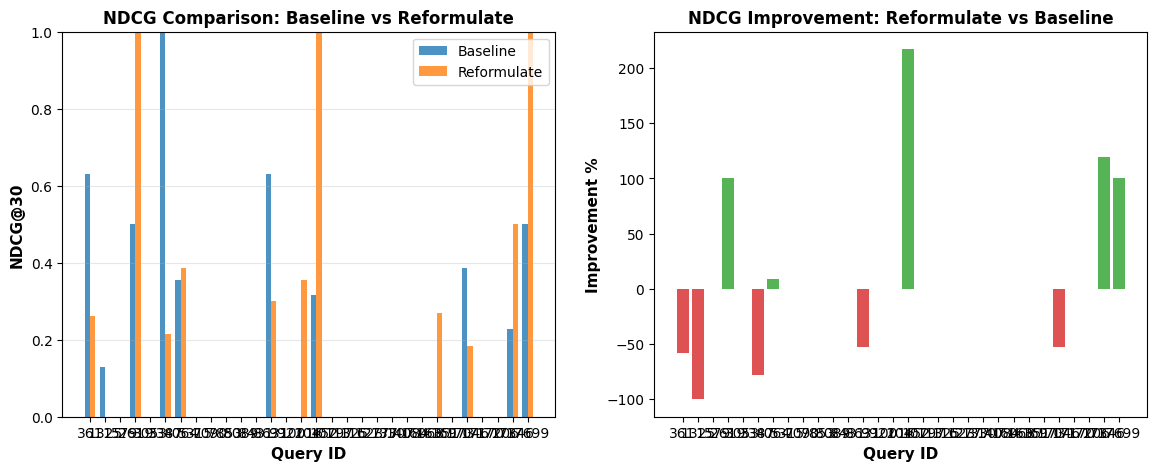

<Figure size 640x480 with 0 Axes>

In [4]:
# ============================================================================
# CELL 4: AGENT COMBINATIONS - Apply selected agent pipeline
# ============================================================================

agent_combo_results_dict = {}
agent_combo_ndcg_scores = {}

print("\n" + "="*80)
print(f"AGENT COMBINATION: {agent_combination_name.upper()}")
print("="*80)

# Process each query
for query_id in sample_queries:
    query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
    query_text = query_row['query_text']
    
    print(f"\nQuery {query_id}: {query_text}")
    
    # Start with baseline retrieval results
    baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
    
    # If no agents selected, skip processing
    if sum(AGENT_SELECTION) == 0:
        final_doc_ids = baseline_doc_ids
        reformulated_query = None
    else:
        current_doc_ids = baseline_doc_ids
        current_scores = baseline_scores
        current_corpus = baseline_corpus
        reformulated_query = None
        
        # Apply agents in order: Reformulate/PRF first, then Reranking
        if AGENT_SELECTION[2]:  # Reformulate (run first if selected)
            expanded_query = apply_reformulate_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K_REFORMULATE)
            print(f"  Expanded query: {expanded_query}")
            # Retrieve with expanded query
            current_doc_ids, current_scores, current_corpus = retriever_func(expanded_query, top_k=TOP_K)
        
        elif AGENT_SELECTION[0]:  # PRF (run first if Reformulate not selected)
            current_doc_ids = apply_prf_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K_PRF)
        
        # Apply Reranking if selected (always last if selected with another agent)
        if AGENT_SELECTION[1] and (AGENT_SELECTION[0] or AGENT_SELECTION[2]):
            current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
        
        elif AGENT_SELECTION[1] and not AGENT_SELECTION[0] and not AGENT_SELECTION[2]:  # Reranking only
            current_doc_ids = apply_reranking_agent(query_text, baseline_doc_ids, baseline_scores, baseline_corpus, TOP_K)
        
        final_doc_ids = current_doc_ids
    
    # Create graded relevance list by looking up actual relevance scores
    graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in final_doc_ids]
    graded_relevance = deduplicate_graded_relevance(final_doc_ids, graded_relevance)
    
    agent_combo_results_dict[query_id] = graded_relevance
    print(f"  Final retrieved docs: {final_doc_ids[:3]}...")
    print(f"  Normalized: {[normalize_doc_id(d) for d in final_doc_ids[:3]]}...")
    print(f"  Graded relevance: {graded_relevance}")
    
    # Calculate NDCG
    ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
    agent_combo_ndcg_scores[query_id] = ndcg
    print(f"  NDCG@{TOP_K}: {ndcg:.4f}")

print("\n" + "="*80)
print(f"{agent_combination_name.upper()} RESULTS")
print("="*80)
for query_id, ndcg in agent_combo_ndcg_scores.items():
    print(f"Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")

agent_combo_mean = np.mean(list(agent_combo_ndcg_scores.values()))
print(f"\nMean {agent_combination_name} NDCG@{TOP_K}: {agent_combo_mean:.4f}")

# ============================================================================
# CELL 5: COMPARATIVE RESULTS TABLE AND VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print(f"COMPARISON TABLE: BASELINE vs {agent_combination_name.upper()}")
print("="*80)

comparison_data = []
for query_id in sample_queries:
    baseline_ndcg = baseline_ndcg_scores[query_id]
    agent_ndcg = agent_combo_ndcg_scores[query_id]
    improvement = agent_ndcg - baseline_ndcg
    improvement_pct = (improvement / baseline_ndcg * 100) if baseline_ndcg > 0 else 0
    
    comparison_data.append({
        'Query ID': query_id,
        'Baseline NDCG': f"{baseline_ndcg:.4f}",
        f'{agent_combination_name} NDCG': f"{agent_ndcg:.4f}",
        'Δ NDCG': f"{improvement:+.4f}",
        'Δ %': f"{improvement_pct:+.2f}%"
    })

df_comparison = pd.DataFrame(comparison_data)

# Display all rows (no truncation)
with pd.option_context('display.max_rows', None):
    print("\n" + df_comparison.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
mean_improvement = agent_combo_mean - baseline_mean

print(f"Baseline Mean NDCG@{TOP_K}: {baseline_mean:.4f}")
print(f"{agent_combination_name} Mean NDCG@{TOP_K}: {agent_combo_mean:.4f}")
print(f"Mean Improvement: {mean_improvement:+.4f}")
print(f"Mean Improvement %: {(mean_improvement/baseline_mean*100):+.2f}%")

queries_improved = sum(1 for qid in sample_queries if agent_combo_ndcg_scores[qid] > baseline_ndcg_scores[qid])
print(f"Queries Improved: {queries_improved}/{len(sample_queries)}")
print("="*80)

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: NDCG Comparison Bar Chart
query_ids_str = [str(qid) for qid in sample_queries]
baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
agent_scores = [agent_combo_ndcg_scores[qid] for qid in sample_queries]

x = np.arange(len(query_ids_str))
width = 0.35

axes[0].bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
axes[0].bar(x + width/2, agent_scores, width, label=agent_combination_name, alpha=0.8, color='#ff7f0e')
axes[0].set_xlabel('Query ID', fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'NDCG@{TOP_K}', fontsize=11, fontweight='bold')
axes[0].set_title(f'NDCG Comparison: Baseline vs {agent_combination_name}', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(query_ids_str)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.0])

# Plot 2: Improvement Percentage
improvements = []
colors = []
for qid in sample_queries:
    imp = ((agent_combo_ndcg_scores[qid] - baseline_ndcg_scores[qid]) / baseline_ndcg_scores[qid] * 100) if baseline_ndcg_scores[qid] > 0 else 0
    improvements.append(imp)
    colors.append('#2ca02c' if imp >= 0 else '#d62728')

axes[1].bar(query_ids_str, improvements, color=colors, alpha=0.8)

axes[1].set_xlabel('Query ID', fontsize=11, fontweight='bold')
print("\n✓ Visualization complete")

axes[1].set_ylabel('Improvement %', fontsize=11, fontweight='bold')

axes[1].set_title(f'NDCG Improvement: {agent_combination_name} vs Baseline', fontsize=12, fontweight='bold')
plt.show()

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()

axes[1].grid(axis='y', alpha=0.3)

axes[1].axhline(y=mean_improvement/baseline_mean*100, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_improvement/baseline_mean*100:+.2f}%')
axes[1].legend()

In [5]:

# ============================================================================
# CELL 6: LOOP ALL COMBINATIONS - Compare all agent combinations
# ============================================================================

# Define all valid combinations
all_combinations = [
    ([0, 0, 0], "Baseline"),
    ([1, 0, 0], "PRF"),
    ([0, 1, 0], "Reranking"),
    ([0, 0, 1], "Reformulate"),
    ([1, 1, 0], "PRF + Reranking"),
    ([1, 0, 1], "PRF + Reformulate"),
    ([0, 1, 1], "Reformulate + Reranking")
]

# Store results for all combinations
all_results = {}

print("\n" + "="*80)
print("EVALUATING ALL AGENT COMBINATIONS")
print("="*80)

for combination, combo_name in all_combinations:
    print(f"\n{'='*80}")
    print(f"RUNNING: {combo_name}")
    print(f"{'='*80}")
    
    # Re-initialize agents for this combination
    temp_agents = {}
    if combination[0]:  # PRF
        temp_agents['PRF'] = PRFAgent(embed_model=encoder, num_expansion_terms=NUM_EXPANSION_TERMS)
    if combination[1]:  # Reranking
        # Suppress model loading output unless VERBOSE is True
        if not VERBOSE:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                temp_agents['Reranking'] = RerankingAgent(embed_model=encoder)
        else:
            temp_agents['Reranking'] = RerankingAgent(embed_model=encoder)
    if combination[2]:  # Reformulate
        temp_agents['Reformulate'] = ReformulationAgent(embed_model=encoder)
    
    # Temporarily update global agents dict for helper functions
    original_agents = agents.copy()
    agents.clear()
    agents.update(temp_agents)
    
    # Run agent combination pipeline
    combo_results_dict = {}
    combo_ndcg_scores = {}
    
    for query_id in sample_queries:
        query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
        query_text = query_row['query_text']
        
        # Start with baseline retrieval results
        baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
        
        # If no agents selected, use baseline
        if sum(combination) == 0:
            final_doc_ids = baseline_doc_ids
        else:
            current_doc_ids = baseline_doc_ids
            current_scores = baseline_scores
            current_corpus = baseline_corpus
            
            # Apply agents in order: Reformulate/PRF first, then Reranking
            # Suppress output unless VERBOSE is True
            output_suppressor = redirect_stdout(io.StringIO()) if not VERBOSE else None
            
            try:
                if output_suppressor:
                    output_suppressor.__enter__()
                
                if combination[2]:  # Reformulate (run first if selected)
                    expanded_query = apply_reformulate_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K_REFORMULATE)
                    current_doc_ids, current_scores, current_corpus = retriever_func(expanded_query, top_k=TOP_K)
                
                elif combination[0]:  # PRF (run first if Reformulate not selected)
                    current_doc_ids = apply_prf_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K_PRF)
                
                # Apply Reranking if selected (always last if selected with another agent)
                if combination[1] and (combination[0] or combination[2]):
                    current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
            finally:
                if output_suppressor:
                    output_suppressor.__exit__(None, None, None)
            
                elif combination[1] and not combination[0] and not combination[2]:  # Reranking only
                    current_doc_ids = apply_reranking_agent(query_text, baseline_doc_ids, baseline_scores, baseline_corpus, TOP_K)
            
            final_doc_ids = current_doc_ids
        
        # Create graded relevance list
        graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in final_doc_ids]
        graded_relevance = deduplicate_graded_relevance(final_doc_ids, graded_relevance)
        combo_results_dict[query_id] = graded_relevance
        
        # Calculate NDCG
        ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
        combo_ndcg_scores[query_id] = ndcg
        if VERBOSE:
            print(f"  Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")
    
    # Store results
    combo_mean = np.mean(list(combo_ndcg_scores.values()))
    improvement = combo_mean - baseline_mean
    improvement_pct = (improvement / baseline_mean * 100) if baseline_mean > 0 else 0
    
    all_results[combo_name] = {
        'ndcg_scores': combo_ndcg_scores,
        'mean_ndcg': combo_mean,
        'improvement': improvement,
        'improvement_pct': improvement_pct
    }
    
    print(f"\nMean NDCG@{TOP_K}: {combo_mean:.4f}")
    print(f"Improvement vs Baseline: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    # Restore original agents dict
    agents.clear()
    agents.update(original_agents)

print("\n" + "="*80)
print("SUMMARY OF ALL COMBINATIONS")
print("="*80)

summary_data = []
for combo_name, results in all_results.items():
    summary_data.append({
        'Agent Combination': combo_name,
        'Mean NDCG': f"{results['mean_ndcg']:.4f}",
        'Improvement': f"{results['improvement']:+.4f}",
        'Improvement %': f"{results['improvement_pct']:+.2f}%"
    })

df_summary = pd.DataFrame(summary_data)
with pd.option_context('display.max_rows', None):
    print("\n" + df_summary.to_string(index=False))

print("\n" + "="*80)
print("GENERATING COMPARISON GRAPHS FOR EACH COMBINATION")
print("="*80)

# Create subplots for all combinations (2x4 grid)
n_combos = len(all_combinations)
n_cols = 4
n_rows = (n_combos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # Flatten for easier iteration

for idx, (combination, combo_name) in enumerate(all_combinations):
    results = all_results[combo_name]
    combo_ndcg_scores = results['ndcg_scores']
    combo_mean = results['mean_ndcg']
    improvement_pct = results['improvement_pct']
    
    ax = axes[idx]
    
    # Prepare data
    query_ids_str = [str(qid) for qid in sample_queries]
    baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
    agent_scores = [combo_ndcg_scores[qid] for qid in sample_queries]
    
    x = np.arange(len(query_ids_str))
    width = 0.35
    
    # Create bar chart
    ax.bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
    ax.bar(x + width/2, agent_scores, width, label=combo_name, alpha=0.8, color='#ff7f0e')
    
    # Format
    ax.set_xlabel('Query ID', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'NDCG@{TOP_K}', fontsize=9, fontweight='bold')
    ax.set_title(f'{combo_name}\n(Δ {improvement_pct:+.2f}%, Mean: {combo_mean:.4f})', 
                 fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(query_ids_str, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])

# Hide unused subplots
for idx in range(n_combos, len(axes)):
    axes[idx].axis('off')


plt.tight_layout()

plt.show()
print("\n✓ All combination graphs generated successfully")



EVALUATING ALL AGENT COMBINATIONS

RUNNING: Baseline

Mean NDCG@30: 0.1559
Improvement vs Baseline: +0.0000 (+0.00%)

RUNNING: PRF


KeyboardInterrupt: 

In [ ]:

# ============================================================================
# CELL 6.2: NEW COMBINATIONS - Custom execution orders
# ============================================================================

# Define NEW combinations with custom execution orders
# These are not standard [a,b,c] arrays but special pipelines
new_combinations_custom = [
    ("Reranking + Reformulate + Reranking", 
     lambda: pipeline_rerank_reformulate_rerank(query_text, baseline_doc_ids, baseline_scores, baseline_corpus)),
    ("Reranking + PRF + Reranking",
     lambda: pipeline_rerank_prf_rerank(query_text, baseline_doc_ids, baseline_scores, baseline_corpus)),
]

# Helper functions for custom pipelines
def pipeline_rerank_reformulate_rerank(query_text, doc_ids, doc_scores, corpus):
    """Reranking -> Reformulate -> Reranking"""
    current_doc_ids = doc_ids
    current_scores = doc_scores
    current_corpus = corpus
    
    # Step 1: Apply Reranking
    current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
    
    # Step 2: Apply Reformulate to expand query based on reranked results
    expanded_query = apply_reformulate_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K_REFORMULATE)
    current_doc_ids, current_scores, current_corpus = retriever_func(expanded_query, top_k=TOP_K)
    
    # Step 3: Apply Reranking again
    current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
    
    return current_doc_ids

def pipeline_rerank_prf_rerank(query_text, doc_ids, doc_scores, corpus):
    """Reranking -> PRF -> Reranking"""
    current_doc_ids = doc_ids
    current_scores = doc_scores
    current_corpus = corpus
    
    # Step 1: Apply Reranking
    current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
    
    # Step 2: Apply PRF to expand query based on reranked results
    current_doc_ids = apply_prf_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K_PRF)
    
    # Step 3: Apply Reranking again
    current_doc_ids = apply_reranking_agent(query_text, current_doc_ids, current_scores, current_corpus, TOP_K)
    
    return current_doc_ids

# Store results for new combinations
new_results = {}

print("\n" + "="*80)
print("EVALUATING NEW CUSTOM AGENT COMBINATIONS")
print("="*80)

# For custom pipelines, we need all agents initialized
custom_agents_needed = {}
custom_agents_needed['Reranking'] = RerankingAgent(embed_model=encoder)
custom_agents_needed['PRF'] = PRFAgent(embed_model=encoder, num_expansion_terms=NUM_EXPANSION_TERMS)
custom_agents_needed['Reformulate'] = ReformulationAgent(embed_model=encoder)

# Temporarily update global agents dict
original_agents = agents.copy()
agents.clear()
agents.update(custom_agents_needed)

for combo_name, pipeline_func in new_combinations_custom:
    print(f"\n{'='*80}")
    print(f"RUNNING: {combo_name}")
    print(f"{'='*80}")
    
    # Run agent combination pipeline
    combo_results_dict = {}
    combo_ndcg_scores = {}
    
    for query_id in sample_queries:
        query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
        query_text = query_row['query_text']
        
        # Start with baseline retrieval results
        baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
        
        output_suppressor = redirect_stdout(io.StringIO()) if not VERBOSE else None
        
        try:
            if output_suppressor:
                output_suppressor.__enter__()
            
            # Execute the custom pipeline
            final_doc_ids = pipeline_func()
            
        finally:
            if output_suppressor:
                output_suppressor.__exit__(None, None, None)
        
        # Create graded relevance list
        graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in final_doc_ids]
        graded_relevance = deduplicate_graded_relevance(final_doc_ids, graded_relevance)
        combo_results_dict[query_id] = graded_relevance
        
        # Calculate NDCG
        ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
        combo_ndcg_scores[query_id] = ndcg
        if VERBOSE:
            print(f"  Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")
    
    # Store results
    combo_mean = np.mean(list(combo_ndcg_scores.values()))
    improvement = combo_mean - baseline_mean
    improvement_pct = (improvement / baseline_mean * 100) if baseline_mean > 0 else 0
    
    new_results[combo_name] = {
        'ndcg_scores': combo_ndcg_scores,
        'mean_ndcg': combo_mean,
        'improvement': improvement,
        'improvement_pct': improvement_pct
    }
    
    print(f"\nMean NDCG@{TOP_K}: {combo_mean:.4f}")
    print(f"Improvement vs Baseline: {improvement:+.4f} ({improvement_pct:+.2f}%)")

# Restore original agents dict
agents.clear()
agents.update(original_agents)

print("\n" + "="*80)
print("SUMMARY OF NEW CUSTOM COMBINATIONS")
print("="*80)

summary_data = []
for combo_name, results in new_results.items():
    summary_data.append({
        'Agent Combination': combo_name,
        'Mean NDCG': f"{results['mean_ndcg']:.4f}",
        'Improvement': f"{results['improvement']:+.4f}",
        'Improvement %': f"{results['improvement_pct']:+.2f}%"
    })

df_new_summary = pd.DataFrame(summary_data)
with pd.option_context('display.max_rows', None):
    print("\n" + df_new_summary.to_string(index=False))

print("\n" + "="*80)
print("GENERATING COMPARISON GRAPHS FOR NEW CUSTOM COMBINATIONS")
print("="*80)

# Create subplots for new combinations
n_combos = len(new_combinations_custom)
fig, axes = plt.subplots(1, n_combos, figsize=(8*n_combos, 5))
if n_combos == 1:
    axes = [axes]  # Wrap single axis in list

for idx, (combo_name, _) in enumerate(new_combinations_custom):
    results = new_results[combo_name]
    combo_ndcg_scores = results['ndcg_scores']
    combo_mean = results['mean_ndcg']
    improvement_pct = results['improvement_pct']
    
    ax = axes[idx]
    
    # Prepare data
    query_ids_str = [str(qid) for qid in sample_queries]
    baseline_scores = [baseline_ndcg_scores[qid] for qid in sample_queries]
    agent_scores = [combo_ndcg_scores[qid] for qid in sample_queries]
    
    x = np.arange(len(query_ids_str))
    width = 0.35
    
    # Create bar chart
    ax.bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#1f77b4')
    ax.bar(x + width/2, agent_scores, width, label=combo_name, alpha=0.8, color='#ff7f0e')
    
    # Format
    ax.set_xlabel('Query ID', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'NDCG@{TOP_K}', fontsize=9, fontweight='bold')
    ax.set_title(f'{combo_name}\n(Δ {improvement_pct:+.2f}%, Mean: {combo_mean:.4f})', 
                 fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(query_ids_str, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()
print("\n✓ All new custom combination graphs generated successfully")



PRF AGENT: EXPANSION TERMS ANALYSIS (1-10)

RUNNING: PRF with 1 expansion terms

Mean NDCG@30: 0.1585 | Median: 0.0000 | Range: [0.0000, 1.0000]
Improvement vs Baseline: +0.0026 (+1.65%) | Queries Improved: 5/30

RUNNING: PRF with 2 expansion terms

Mean NDCG@30: 0.1558 | Median: 0.0000 | Range: [0.0000, 1.0000]
Improvement vs Baseline: -0.0001 (-0.06%) | Queries Improved: 4/30

RUNNING: PRF with 3 expansion terms

Mean NDCG@30: 0.1613 | Median: 0.0000 | Range: [0.0000, 1.0000]
Improvement vs Baseline: +0.0054 (+3.45%) | Queries Improved: 5/30

RUNNING: PRF with 4 expansion terms

Mean NDCG@30: 0.1466 | Median: 0.0000 | Range: [0.0000, 1.0000]
Improvement vs Baseline: -0.0093 (-5.99%) | Queries Improved: 4/30

RUNNING: PRF with 5 expansion terms

Mean NDCG@30: 0.1172 | Median: 0.0000 | Range: [0.0000, 0.6309]
Improvement vs Baseline: -0.0387 (-24.83%) | Queries Improved: 3/30

RUNNING: PRF with 6 expansion terms

Mean NDCG@30: 0.1122 | Median: 0.0000 | Range: [0.0000, 0.6309]
Improvem

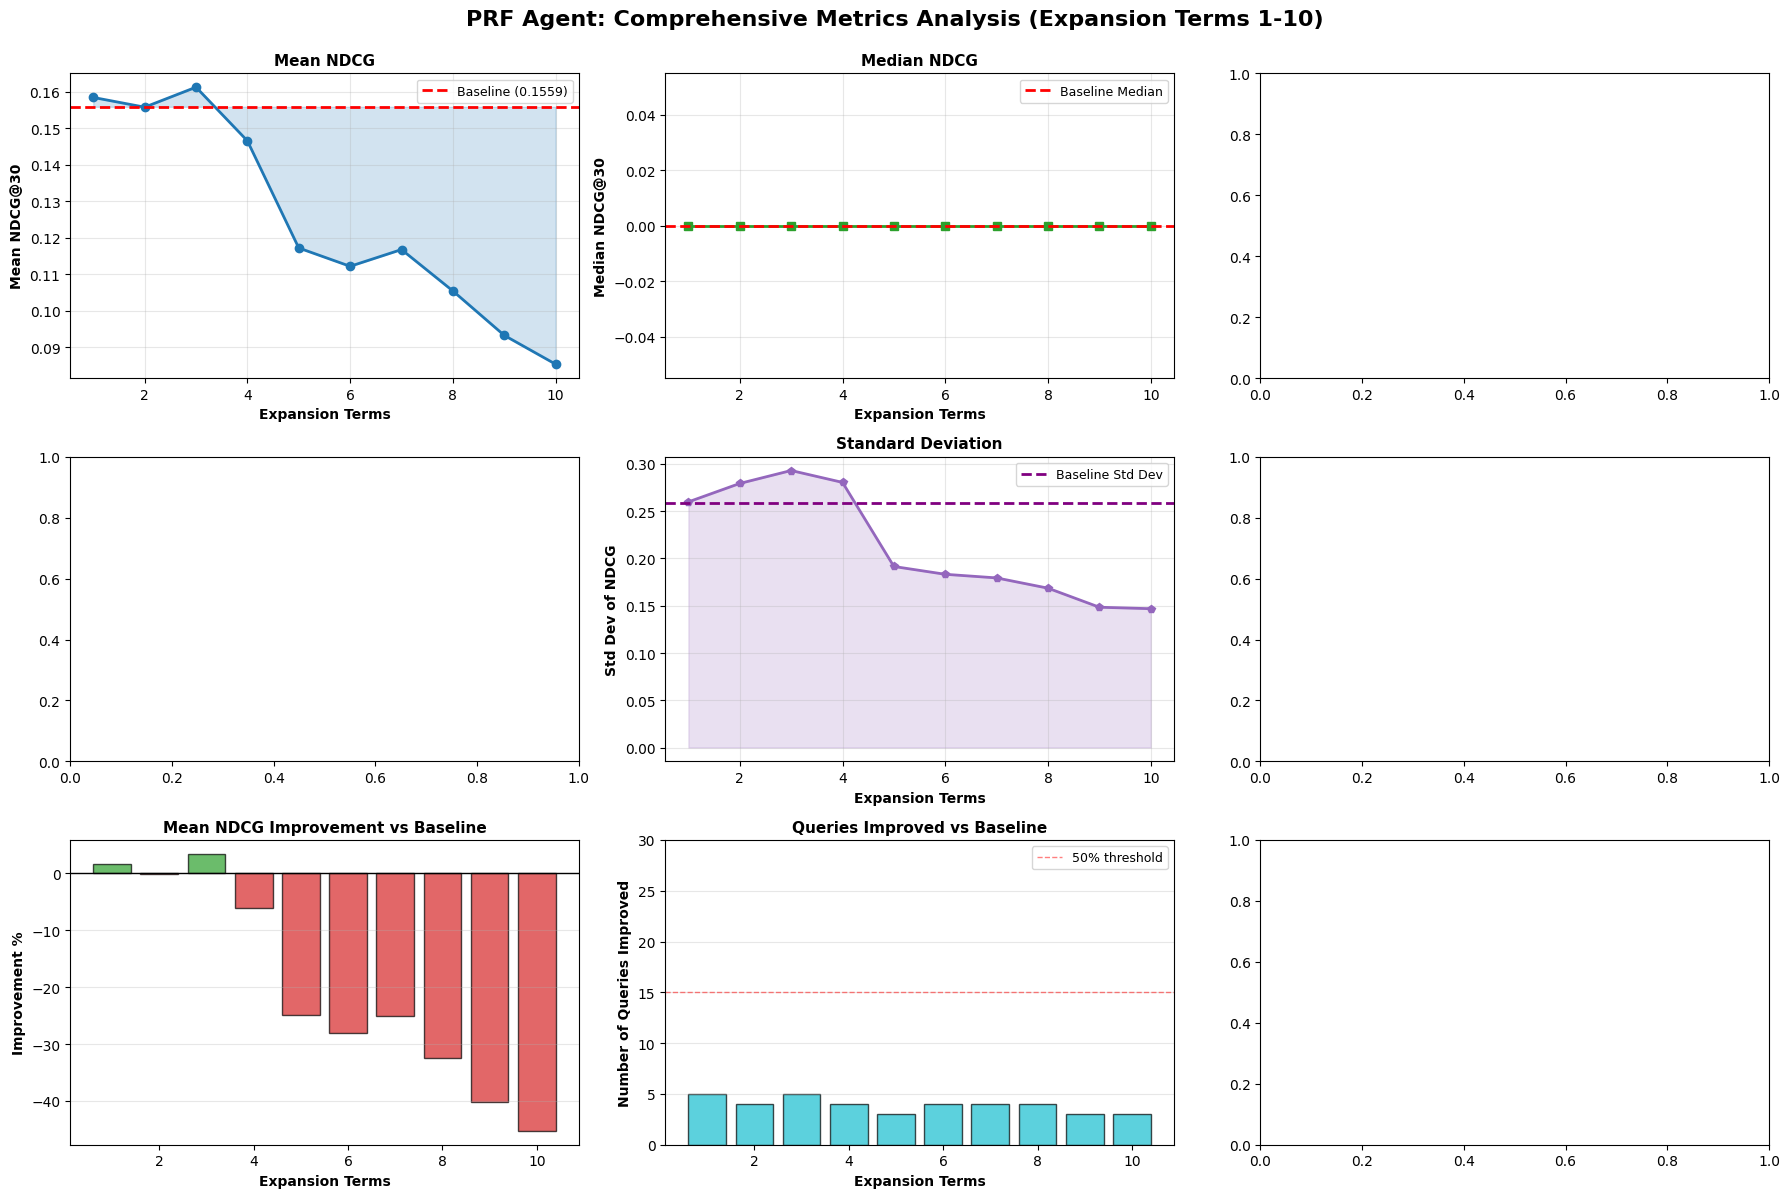


✓ All metric plots generated successfully


In [ ]:

# ============================================================================
# CELL 7: PRF EXPANSION TERMS ANALYSIS - Loop expansion terms (tunable)
# ============================================================================

# ===== EXPANSION TERMS RANGE =====
MIN_EXPANSION_TERMS = 1
MAX_EXPANSION_TERMS = 10

print("\n" + "="*80)
print(f"PRF AGENT: EXPANSION TERMS ANALYSIS ({MIN_EXPANSION_TERMS}-{MAX_EXPANSION_TERMS})")
print("="*80)


# Store results for all expansion terms
expansion_results = {}

# Loop through expansion terms
for num_terms in range(MIN_EXPANSION_TERMS, MAX_EXPANSION_TERMS + 1):
    print(f"\n{'='*80}")
    print(f"RUNNING: PRF with {num_terms} expansion terms")
    print(f"{'='*80}")
    
    # Initialize PRF agent with current expansion term count
    temp_agents = {'PRF': PRFAgent(embed_model=encoder, num_expansion_terms=num_terms)}
    
    # Temporarily update global agents dict
    original_agents = agents.copy()
    agents.clear()
    agents.update(temp_agents)
    
    # Run PRF agent pipeline
    term_ndcg_scores = {}
    
    for query_id in sample_queries:
        query_row = df_qrels[df_qrels['query_id'] == query_id].iloc[0]
        query_text = query_row['query_text']
        
        # Get baseline retrieval results
        baseline_doc_ids, baseline_scores, baseline_corpus = baseline_raw_results[query_id]
        
        # Apply PRF agent with output suppression unless VERBOSE is True
        output_suppressor = redirect_stdout(io.StringIO()) if not VERBOSE else None
        
        try:
            if output_suppressor:
                output_suppressor.__enter__()
            
            prf_doc_ids = apply_prf_agent(query_text, baseline_doc_ids, baseline_scores, baseline_corpus, TOP_K_PRF)
        finally:
            if output_suppressor:
                output_suppressor.__exit__(None, None, None)
        
        # Create graded relevance list
        graded_relevance = [qrels_lookup.get((query_id, normalize_doc_id(doc_id)), 0) for doc_id in prf_doc_ids]
        graded_relevance = deduplicate_graded_relevance(prf_doc_ids, graded_relevance)
        # Calculate NDCG
        ndcg = compute_ndcg(graded_relevance, query_id, k=TOP_K)
        term_ndcg_scores[query_id] = ndcg
        if VERBOSE:
            print(f"  Query {query_id}: NDCG@{TOP_K} = {ndcg:.4f}")
    
    # Store results with comprehensive metrics
    ndcg_values = list(term_ndcg_scores.values())
    term_mean = np.mean(ndcg_values)
    term_median = np.median(ndcg_values)
    term_min = np.min(ndcg_values)
    term_max = np.max(ndcg_values)
    term_std = np.std(ndcg_values)
    term_var = np.var(ndcg_values)
    term_range = term_max - term_min
    improvement = term_mean - baseline_mean
    improvement_pct = (improvement / baseline_mean * 100) if baseline_mean > 0 else 0
    
    # Count queries that improved over baseline
    queries_improved = sum(1 for qid in sample_queries if term_ndcg_scores[qid] > baseline_ndcg_scores[qid])
    
    expansion_results[num_terms] = {
        'ndcg_scores': term_ndcg_scores,
        'mean_ndcg': term_mean,
        'median_ndcg': term_median,
        'min_ndcg': term_min,
        'max_ndcg': term_max,
        'std_ndcg': term_std,
        'var_ndcg': term_var,
        'range_ndcg': term_range,
        'improvement': improvement,
        'improvement_pct': improvement_pct,
        'queries_improved': queries_improved
    }

    print(f"\nMean NDCG@{TOP_K}: {term_mean:.4f} | Median: {term_median:.4f} | Range: [{term_min:.4f}, {term_max:.4f}]")
    print(f"Improvement vs Baseline: {improvement:+.4f} ({improvement_pct:+.2f}%) | Queries Improved: {queries_improved}/{len(sample_queries)}")
    
    # Restore original agents dict
    agents.clear()
    agents.update(original_agents)

print("\n" + "="*80)
print("SUMMARY: PRF EXPANSION TERMS ({}-{})".format(MIN_EXPANSION_TERMS, MAX_EXPANSION_TERMS))
print("="*80)

summary_data = []
for num_terms, results in expansion_results.items():
    summary_data.append({
        'Expansion Terms': num_terms,
        'Mean': f"{results['mean_ndcg']:.4f}",
        'Median': f"{results['median_ndcg']:.4f}",
        'Min': f"{results['min_ndcg']:.4f}",
        'Max': f"{results['max_ndcg']:.4f}",
        'Std Dev': f"{results['std_ndcg']:.4f}",
        'Variance': f"{results['var_ndcg']:.6f}",
        'Range': f"{results['range_ndcg']:.4f}",
        'Improvement %': f"{results['improvement_pct']:+.2f}%",
        'Queries Improved': f"{results['queries_improved']}/{len(sample_queries)}"
    })

df_expansion_summary = pd.DataFrame(summary_data)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print("\n" + df_expansion_summary.to_string(index=False))

print("\n" + "="*80)
print("GENERATING METRIC PLOTS FOR EACH EXPANSION TERM")
print("="*80)

expansion_terms = list(expansion_results.keys())

# Extract metrics for plotting
mean_ndcgs = [expansion_results[t]['mean_ndcg'] for t in expansion_terms]
median_ndcgs = [expansion_results[t]['median_ndcg'] for t in expansion_terms]
min_ndcgs = [expansion_results[t]['min_ndcg'] for t in expansion_terms]
max_ndcgs = [expansion_results[t]['max_ndcg'] for t in expansion_terms]
std_ndcgs = [expansion_results[t]['std_ndcg'] for t in expansion_terms]
var_ndcgs = [expansion_results[t]['var_ndcg'] for t in expansion_terms]
improvement_pcts = [expansion_results[t]['improvement_pct'] for t in expansion_terms]
queries_improved_counts = [expansion_results[t]['queries_improved'] for t in expansion_terms]

# Create comprehensive metric plots (3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle(f'PRF Agent: Comprehensive Metrics Analysis (Expansion Terms {MIN_EXPANSION_TERMS}-{MAX_EXPANSION_TERMS})', 
             fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Mean NDCG
ax = axes[0, 0]
ax.plot(expansion_terms, mean_ndcgs, marker='o', linewidth=2, markersize=6, color='#1f77b4')
ax.axhline(y=baseline_mean, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_mean:.4f})')
ax.fill_between(expansion_terms, baseline_mean, mean_ndcgs, alpha=0.2, color='#1f77b4')
ax.set_xlabel('Expansion Terms', fontsize=10, fontweight='bold')
ax.set_ylabel(f'Mean NDCG@{TOP_K}', fontsize=10, fontweight='bold')
ax.set_title('Mean NDCG', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# Plot 2: Median NDCG
ax = axes[0, 1]
ax.plot(expansion_terms, median_ndcgs, marker='s', linewidth=2, markersize=6, color='#2ca02c')
ax.axhline(y=np.median(list(baseline_ndcg_scores.values())), color='red', linestyle='--', linewidth=2, label='Baseline Median')
ax.fill_between(expansion_terms, np.median(list(baseline_ndcg_scores.values())), median_ndcgs, alpha=0.2, color='#2ca02c')
ax.set_xlabel('Expansion Terms', fontsize=10, fontweight='bold')
ax.set_ylabel(f'Median NDCG@{TOP_K}', fontsize=10, fontweight='bold')
ax.set_title('Median NDCG', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)


# Plot 5: Standard Deviation
ax = axes[1, 1]
ax.plot(expansion_terms, std_ndcgs, marker='p', linewidth=2, markersize=6, color='#9467bd')
ax.axhline(y=np.std(list(baseline_ndcg_scores.values())), color='purple', linestyle='--', linewidth=2, label='Baseline Std Dev')
ax.fill_between(expansion_terms, 0, std_ndcgs, alpha=0.2, color='#9467bd')
ax.set_xlabel('Expansion Terms', fontsize=10, fontweight='bold')
ax.set_ylabel('Std Dev of NDCG', fontsize=10, fontweight='bold')
ax.set_title('Standard Deviation', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)


# Plot 7: Improvement %
ax = axes[2, 0]
colors = ['#2ca02c' if imp >= 0 else '#d62728' for imp in improvement_pcts]
ax.bar(expansion_terms, improvement_pcts, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Expansion Terms', fontsize=10, fontweight='bold')
ax.set_ylabel('Improvement %', fontsize=10, fontweight='bold')
ax.set_title('Mean NDCG Improvement vs Baseline', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 8: Queries Improved Count
ax = axes[2, 1]
ax.bar(expansion_terms, queries_improved_counts, color='#17becf', alpha=0.7, edgecolor='black', linewidth=1)
ax.axhline(y=len(sample_queries)/2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
ax.set_xlabel('Expansion Terms', fontsize=10, fontweight='bold')
ax.set_ylabel(f'Number of Queries Improved', fontsize=10, fontweight='bold')
ax.set_title('Queries Improved vs Baseline', fontsize=11, fontweight='bold')
ax.set_ylim([0, len(sample_queries)])
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9)



plt.tight_layout()
plt.show()

print("\n✓ All metric plots generated successfully")
